In [73]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

In [74]:
# 1. Generate a Synthetic Sine Wave Dataset
def generate_sine_wave(seq_length=100, num_samples=1000):
    x = np.linspace(0, 50, num_samples)
    y = np.sin(x)
    return y


In [75]:
# 2. Prepare the Dataset for RNN
def create_dataset(data, time_step=10):
    X, y = [], []
    for i in range(len(data) - time_step - 1):
        X.append(data[i:(i + time_step)])
        y.append(data[i + time_step])
    return np.array(X), np.array(y)

In [76]:
# Generate and Normalize the Data
data = generate_sine_wave()
scaler = MinMaxScaler(feature_range=(0, 1))
data = scaler.fit_transform(data.reshape(-1, 1)).reshape(-1)

In [77]:
# Create the Dataset
time_step = 10  # Time steps for RNN input
X, y = create_dataset(data, time_step)

In [78]:
# Reshape for RNN input [samples, time steps, features]
X = X.reshape(X.shape[0], X.shape[1], 1)


In [79]:
# Split the Data into Training and Testing Sets (80% train, 20% test)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


In [80]:
# 3. Define the RNN Model
model = Sequential()
model.add(SimpleRNN(units=22, return_sequences=False, input_shape=(time_step, 1)))  # <-- Tune 'units'
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [81]:
# 4. Train the Model
model.fit(X_train, y_train, epochs=40, batch_size=32, verbose=1)  # <-- Experiment with 'epochs' and 'batch_size'

Epoch 1/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4524   
Epoch 2/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0310 
Epoch 3/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0094 
Epoch 4/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0043 
Epoch 5/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0023 
Epoch 6/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0012 
Epoch 7/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8.2205e-04
Epoch 8/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.9301e-04 
Epoch 9/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.3042e-04 
Epoch 10/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.5675e-04 
Epoch 11/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.8422e-04 
Epoch 12/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.0511e-04 
Epoch 13/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.8052e-04 
Epoch 14/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.3442e-04
Epoch 15/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 

In [82]:
# 5. Predict on the Test Data
y_pred = model.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


In [83]:
# Inverse transform to get the original scale (if normalization was applied)
y_pred = scaler.inverse_transform(y_pred.reshape(-1, 1)).reshape(-1)
y_test = scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(-1)

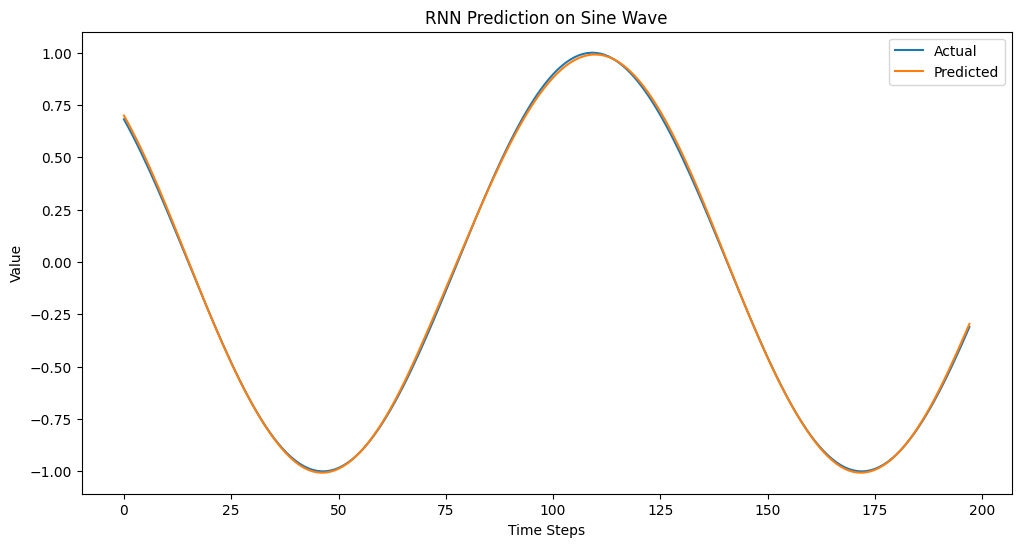

In [84]:

# 6. Plot the Results
plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.xlabel('Time Steps')
plt.ylabel('Value')
plt.title('RNN Prediction on Sine Wave')
plt.legend()
plt.show()

I increased the number of units to 22 and the epochs to 40. At that time, the actual and predicted values became more similar

1. Increasing units (22 instead of 15)
More units = the model has more capacity to learn complex relationships in your sequence data.
With 22 units, the network could capture more features, leading to better predictions.

2. Increasing epochs (40 instead of fewer)
More epochs = the model has more chances to adjust weights and reduce error.
This improves the match between predicted and actual values.

In [85]:
model.save("IT22354938Q1.h5")
